# Regression Analysis

In this notebook, the representations of characters are analyzed in terms of similarity explained by other meaniningful factors, including acoustic similarity, semantic similarity, visual similarity, and pinyin similarity.

The work is organized as follows:
1. Context Dependent Representations: the representations are extracted, the framework for pairing is employed.
2. EDA: explaratory analysis of the pair similarity data.
3. Modeling: direct modeling of effect using linear regresession.
4. PCA: hidden similarity decomposition to first K principal components.
5. Multicollinearity Test: VIF values.
6. Linearity and Heteroscedasticity: Test of applicability of linear modeling.
7. Cross-Validation: $R^2$ validation.
8. Non-linear Modeling: Nonlinear features, Decision Tree, and XGBoost regression for the same data.
9. SHAP Values: explaining key influential factors.
10. Mixed Effects Regression: decoupling dependency on characters from effects. Estimating the significance of the characters itself

## Context Dependent Representations

### Data Preparation

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

contextual_records = joblib.load('')

In [2]:
len(contextual_records)

299061

In [3]:
contextual_records[0].keys()

dict_keys(['char', 'pinyin', 'hidden', 'acoustic', 'semantic', 'wubi_set', 'pinyin_components'])

In [4]:
# contextual_records[0]

### Combinations Evaluation

In [5]:
!rm -rf /kaggle/working/contextual_pair_similarities_balanced.csv

In [6]:
import random
import csv
import numpy as np
from tqdm import tqdm
from collections import defaultdict

# Helper functions (same as before)
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def jaccard_similarity(set_a, set_b):
    if not set_a or not set_b:
        return 0.0
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0

def pinyin_flags(comp_i, comp_j):
    init_i, final_i, tone_i = comp_i
    init_j, final_j, tone_j = comp_j

    same_syllable = (init_i == init_j and final_i == final_j and tone_i == tone_j)
    same_initial_final = (not same_syllable and init_i == init_j and final_i == final_j)
    same_initial = (not same_syllable and not same_initial_final and init_i == init_j)
    same_final = (not same_syllable and not same_initial_final and final_i == final_j)
    same_tone = (not same_syllable and not same_initial_final and not same_initial and not same_final and tone_i == tone_j)
    return int(same_initial_final), int(same_initial), int(same_final), int(same_tone)

def get_phonetic_category(comp_i, comp_j):
    sif, si, sf, st = pinyin_flags(comp_i, comp_j)
    if sif:   return 'same_initial_final'
    if si:   return 'same_initial'
    if sf:  return 'same_final'
    if st:   return 'same_tone'
    return 'none'

# Wubi Jaccard bins
BINS = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
def get_wubi_bin(jaccard):
    for i in range(len(BINS)-1):
        if BINS[i] <= jaccard < BINS[i+1]:
            return i
    return len(BINS)-2

TARGET_PER_STRATUM = 5000
MAX_ITER = 10_000_000

strata = defaultdict(list)
sampled_global = set()          # stores (i, j) index pairs
sampled_keys = set()            # stores canonical ordered tuple (char_i, char_j, pinyin_i, pinyin_j)s

N = len(contextual_records)
random.seed(42)

pbar = tqdm(total=MAX_ITER, desc="Stratified sampling")
for _ in range(MAX_ITER):
    i = random.randrange(N)
    j = random.randrange(N)
    if i == j:
        continue
    if i > j:
        i, j = j, i
    # Check index pair already sampled
    if (i, j) in sampled_global:
        continue

    rec_i = contextual_records[i]
    rec_j = contextual_records[j]

    # Skip identical (character, pinyin) pairs
    if rec_i['char'] == rec_j['char'] and rec_i['pinyin'] == rec_j['pinyin']:
        continue

    # Create canonical key for unordered (char, pinyin) pair
    # Use alphabetical order of (char_i, pinyin_i) vs (char_j, pinyin_j)
    key1 = (rec_i['char'], rec_i['pinyin'], rec_j['char'], rec_j['pinyin'])
    key2 = (rec_j['char'], rec_j['pinyin'], rec_i['char'], rec_i['pinyin'])
    if key1 in sampled_keys or key2 in sampled_keys:
        continue

    comp_i = rec_i['pinyin_components']
    comp_j = rec_j['pinyin_components']
    cat = get_phonetic_category(comp_i, comp_j)
    w_jac = jaccard_similarity(rec_i['wubi_set'], rec_j['wubi_set'])
    # w_bin = get_wubi_bin(w_jac)
    # key = (cat, w_bin)

    key = cat

    if len(strata[key]) < TARGET_PER_STRATUM:
        strata[key].append((i, j))
        sampled_global.add((i, j))
        sampled_keys.add(key1)
        sampled_keys.add(key2)

    # Stop if all strata (that have appeared) are full
    if all(len(lst) >= TARGET_PER_STRATUM for lst in strata.values()):
        break

    pbar.update(1)

pbar.close()
# print(f"Sampled pairs per stratum:")
# for (cat, bin_idx), lst in sorted(strata.items()):
#     print(f"  {cat}, bin {BINS[bin_idx]:.1f}-{BINS[bin_idx+1]:.1f}: {len(lst)}")

# Write to CSV (same as before)
out_fname = 'contextual_pair_similarities_balanced.csv'
with open(out_fname, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['char_i', 'char_j', 'pinyin_i', 'pinyin_j', 'hidden_sim', 'semantic_sim',
                     'acoustic_sim', 'wubi_jaccard', 'same_initial_final', 'same_initial',
                     'same_final', 'same_tone'])
    # for (cat, bin_idx), pair_list in tqdm(strata.items(), desc="Writing CSV"):
    for cat, pair_list in tqdm(strata.items(), desc="Writing CSV"):
        for i, j in pair_list:
            rec_i = contextual_records[i]
            rec_j = contextual_records[j]
            h_sim = cosine_similarity(rec_i['hidden'], rec_j['hidden'])
            s_sim = cosine_similarity(rec_i['semantic'], rec_j['semantic'])
            a_sim = cosine_similarity(rec_i['acoustic'], rec_j['acoustic'])
            w_jac = jaccard_similarity(rec_i['wubi_set'], rec_j['wubi_set'])
            sf, si, sf_, st = pinyin_flags(rec_i['pinyin_components'], rec_j['pinyin_components'])
            writer.writerow([rec_i['char'], rec_j['char'], rec_i['pinyin'], rec_j['pinyin'],
                             h_sim, s_sim, a_sim, w_jac, sf, si, sf_, st])

print(f"Saved balanced dataset to {out_fname}")

Writing CSV: 100%|██████████| 5/5 [00:01<00:00,  4.75it/s]

Saved balanced dataset to contextual_pair_similarities_balanced.csv


In [7]:
print(f"Sampled pairs per stratum:")
for cat, lst in sorted(strata.items()):
    print(f"  {cat}: {len(lst)}")

Sampled pairs per stratum:
  none: 5000
  same_final: 5000
  same_initial: 5000
  same_initial_final: 4501
  same_tone: 5000


In [8]:
similarity_df = pd.read_csv("/kaggle/working/contextual_pair_similarities_balanced.csv")

In [9]:
similarity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24501 entries, 0 to 24500
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   char_i              24501 non-null  object 
 1   char_j              24501 non-null  object 
 2   pinyin_i            24501 non-null  object 
 3   pinyin_j            24501 non-null  object 
 4   hidden_sim          24501 non-null  float64
 5   semantic_sim        24501 non-null  float64
 6   acoustic_sim        24501 non-null  float64
 7   wubi_jaccard        24501 non-null  float64
 8   same_initial_final  24501 non-null  int64  
 9   same_initial        24501 non-null  int64  
 10  same_final          24501 non-null  int64  
 11  same_tone           24501 non-null  int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 2.2+ MB


In [10]:
similarity_df.describe()

,hidden_sim,semantic_sim,acoustic_sim,wubi_jaccard,same_initial_final,same_initial,same_final,same_tone
count,24501.000000,24501.000000,24501.000000,24501.000000,24501.000000,24501.000000,24501.000000,24501.000000
mean,0.816062,0.314889,0.198928,0.068407,0.183707,0.204073,0.204073,0.204073
std,0.092822,0.219994,0.278115,0.131026,0.387253,0.403031,0.403031,0.403031
min,0.344826,-0.204717,-0.486336,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.756610,0.142622,-0.014229,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.825610,0.285151,0.164685,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.885271,0.462863,0.404347,0.142857,0.000000,0.000000,0.000000,0.000000
max,0.998960,0.966117,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## EDA

### Target Variable

<Axes: xlabel='hidden_sim', ylabel='Density'>

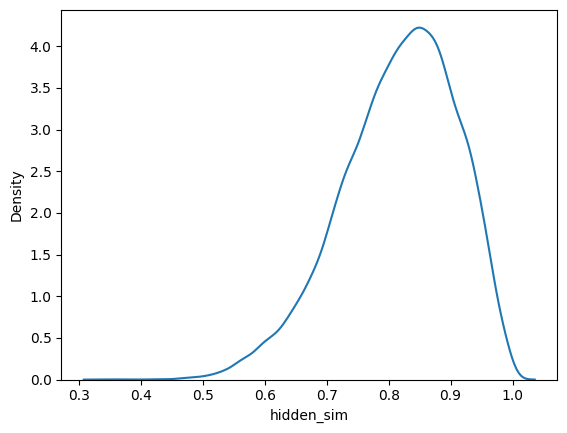

In [11]:
import seaborn as sns

sns.kdeplot(similarity_df, x='hidden_sim')

In [12]:
similarity_df[similarity_df['hidden_sim'] > 0.95]

,char_i,char_j,pinyin_i,pinyin_j,hidden_sim,semantic_sim,acoustic_sim,wubi_jaccard,same_initial_final,same_initial,same_final,same_tone
99,评,平,ping2,ping2,0.994350,0.915245,1.000000,0.666667,0,0,0,0
635,中,终,zhong1,zhong1,0.998960,0.966117,1.000000,0.000000,0,0,0,0
1187,模,我,mo2,wo3,0.963842,0.068732,0.452122,0.000000,0,0,0,0
1325,斯,司,si1,si1,0.998610,0.963564,1.000000,0.000000,0,0,0,0
1500,加,家,jia1,jia1,0.993607,0.915856,1.000000,0.000000,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
24467,泉,劝,quan2,quan4,0.963033,0.764488,0.635795,0.000000,1,0,0,0
24470,辆,良,liang4,liang2,0.978142,0.740297,0.444806,0.000000,1,0,0,0
24491,余,予,yu2,yu3,0.985886,0.609535,0.949675,0.000000,1,0,0,0
24495,理,璃,li3,li2,0.988406,0.756618,0.881225,0.250000,1,0,0,0


### Acoustic Similarity

<Axes: xlabel='acoustic_sim', ylabel='Density'>

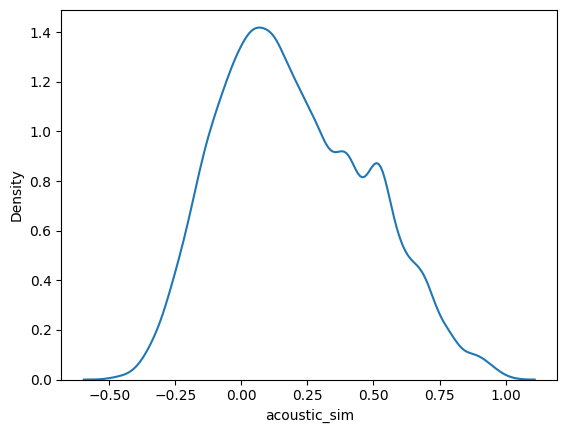

In [13]:
import seaborn as sns

sns.kdeplot(similarity_df, x='acoustic_sim')

In [14]:
similarity_df[similarity_df['acoustic_sim'] > 0.99]

,char_i,char_j,pinyin_i,pinyin_j,hidden_sim,semantic_sim,acoustic_sim,wubi_jaccard,same_initial_final,same_initial,same_final,same_tone
99,评,平,ping2,ping2,0.994350,0.915245,1.0,0.666667,0,0,0,0
635,中,终,zhong1,zhong1,0.998960,0.966117,1.0,0.000000,0,0,0,0
1325,斯,司,si1,si1,0.998610,0.963564,1.0,0.000000,0,0,0,0
1500,加,家,jia1,jia1,0.993607,0.915856,1.0,0.000000,0,0,0,0
1505,是,释,shi4,shi4,0.998598,0.933410,1.0,0.000000,0,0,0,0
2211,是,事,shi4,shi4,0.997305,0.899461,1.0,0.000000,0,0,0,0
2547,未,位,wei4,wei4,0.995824,0.913399,1.0,0.000000,0,0,0,0
3038,实,十,shi2,shi2,0.997933,0.937411,1.0,0.000000,0,0,0,0
3214,和,荷,he2,he2,0.992694,0.855342,1.0,0.000000,0,0,0,0
3280,心,新,xin1,xin1,0.996597,0.936753,1.0,0.000000,0,0,0,0


### Wubi Jaccard Similarity

<Axes: xlabel='wubi_jaccard', ylabel='Density'>

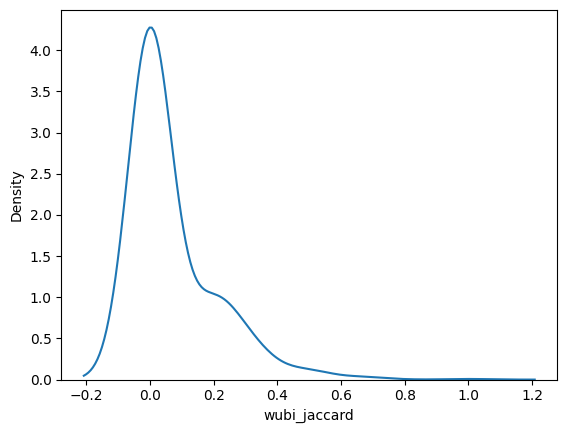

In [15]:
import seaborn as sns

sns.kdeplot(similarity_df, x='wubi_jaccard', bw_adjust=4)

### Semantic Similarity

<Axes: xlabel='semantic_sim', ylabel='Density'>

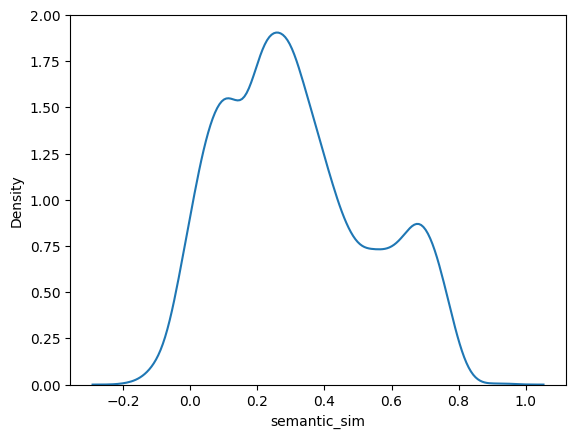

In [16]:
import seaborn as sns

sns.kdeplot(similarity_df, x='semantic_sim')

### Pinyin

<Axes: xlabel='same_initial_final', ylabel='Count'>

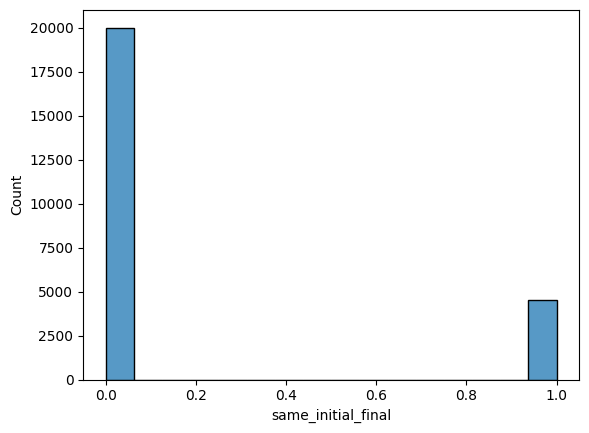

In [17]:
import seaborn as sns

sns.histplot(similarity_df, x='same_initial_final')

<Axes: xlabel='same_initial', ylabel='Count'>

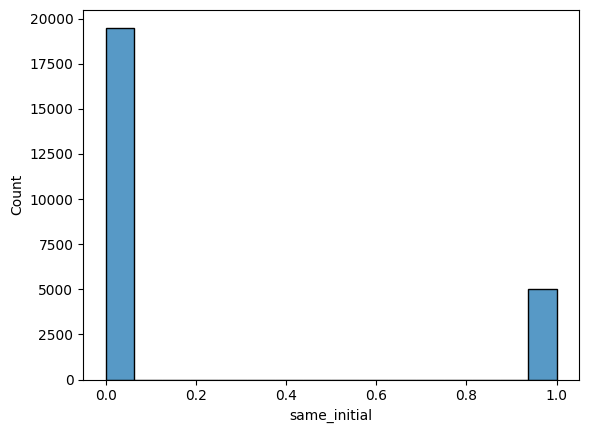

In [18]:
import seaborn as sns

sns.histplot(similarity_df, x='same_initial')

<Axes: xlabel='same_final', ylabel='Count'>

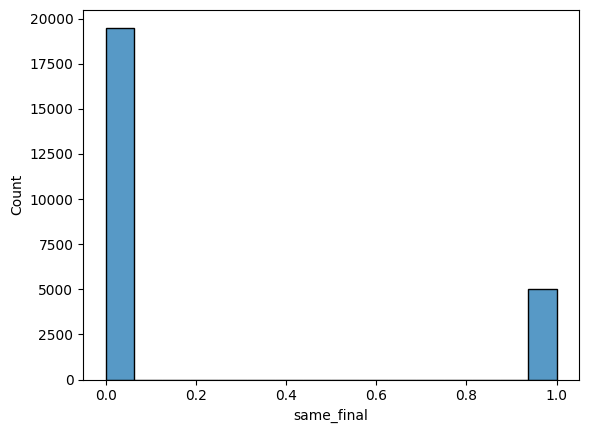

In [19]:
import seaborn as sns

sns.histplot(similarity_df, x='same_final')

<Axes: xlabel='same_tone', ylabel='Count'>

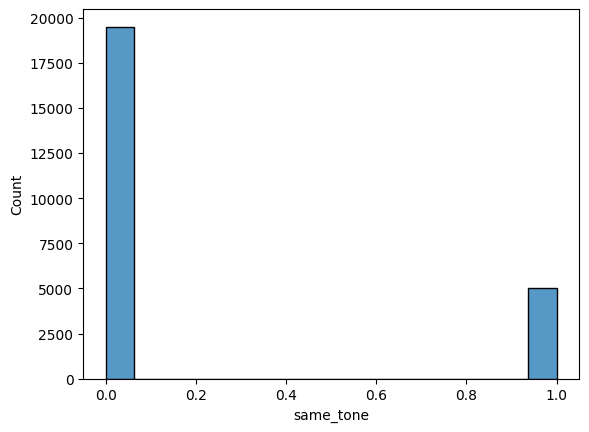

In [20]:
import seaborn as sns

sns.histplot(similarity_df, x='same_tone')

### Correlations

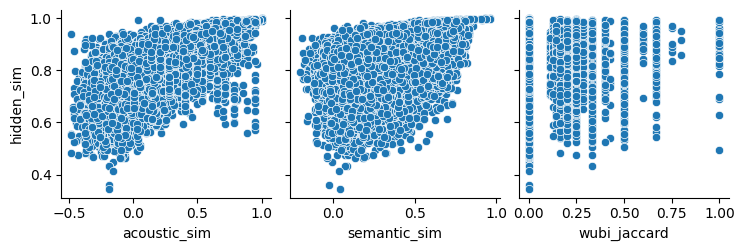

In [21]:
sns.pairplot(similarity_df, x_vars=['acoustic_sim', 'semantic_sim', 'wubi_jaccard'], y_vars=['hidden_sim'])

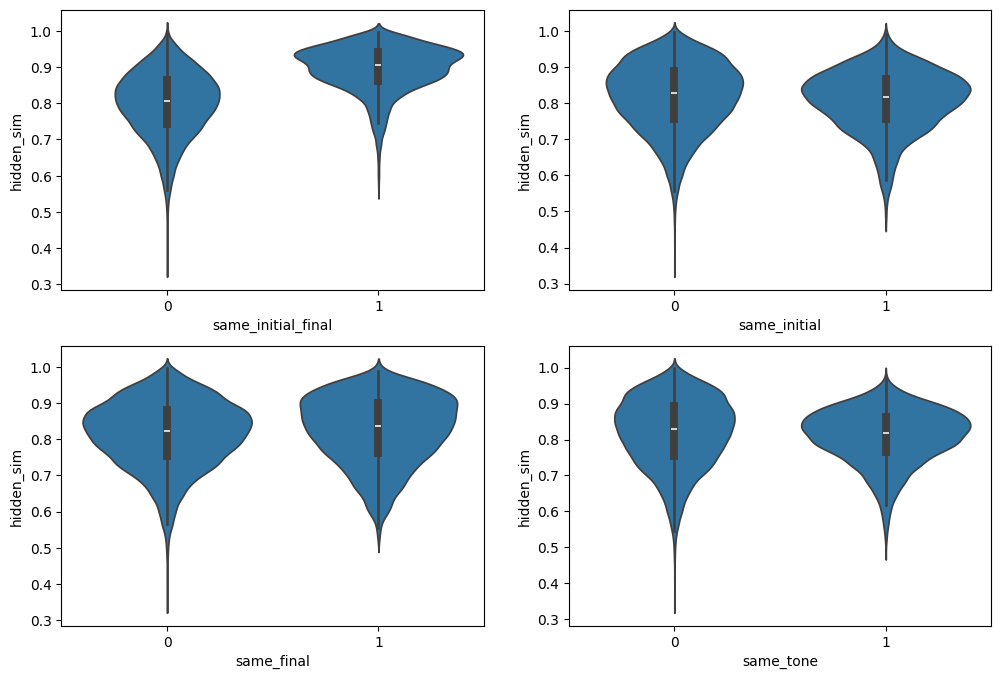

In [22]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

axs = axs.flatten()

names = ['same_initial_final', 'same_initial', 'same_final', 'same_tone']

for i, ax in enumerate(axs):
    sns.violinplot(data=similarity_df, 
               x=names[i], 
               y='hidden_sim', 
               ax=ax)
plt.show()

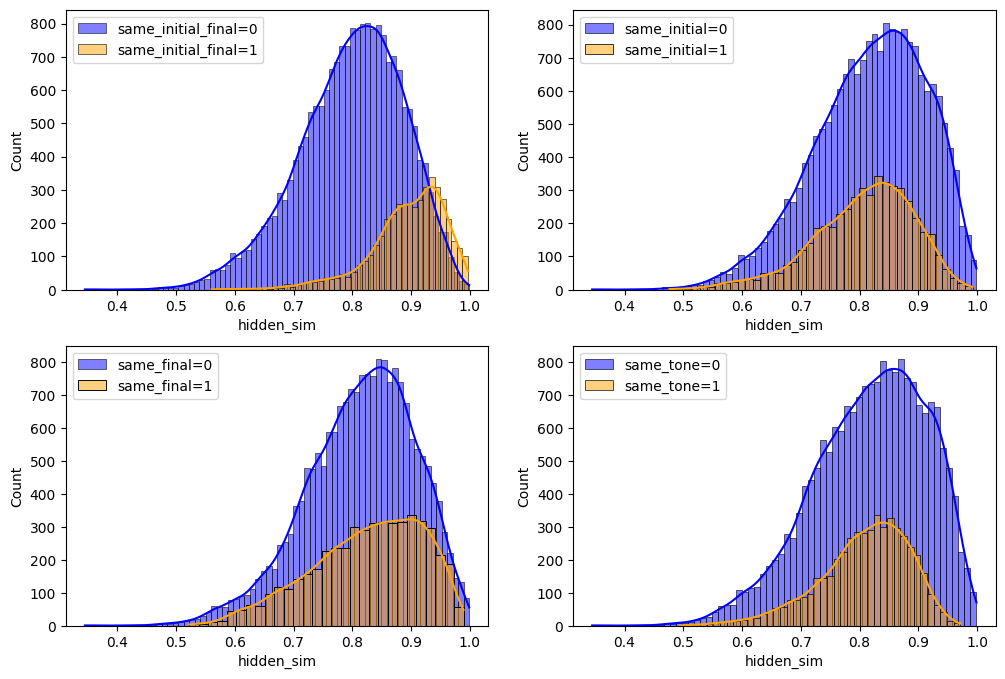

In [23]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

axs = axs.flatten()

names = ['same_initial_final', 'same_initial', 'same_final', 'same_tone']

for i, ax in enumerate(axs):
    for group, color in zip([0, 1], ['blue', 'orange']):
        subset = similarity_df[similarity_df[names[i]] == group]
        sns.histplot(subset['hidden_sim'], 
                     label=f'{names[i]}={group}', 
                     color=color, 
                     kde=True, 
                     alpha=0.5, 
                     ax=ax)
    ax.legend()
plt.show()

<Axes: >

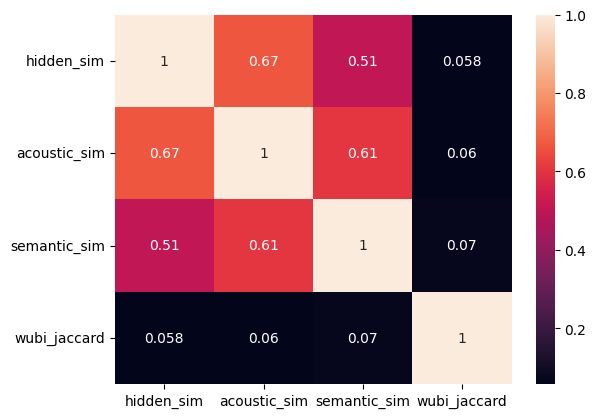

In [24]:
import seaborn as sns

sns.heatmap(similarity_df[[
            'hidden_sim', 'acoustic_sim',
            'semantic_sim', 'wubi_jaccard'
]].corr(method='pearson'), annot=True)

## Modeling

Linear regression fit to explain effects.

### Train/Test Split

In [25]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import r2_score


X = similarity_df[[
    'semantic_sim',
    'acoustic_sim',
    'wubi_jaccard',
    'same_initial_final',
    'same_initial',
    'same_final',
    'same_tone'
]]

X = sm.add_constant(X)

y = similarity_df['hidden_sim']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scaling

**Standard scaling** is applied to normalize effects.

In [26]:
from sklearn.preprocessing import StandardScaler

scaling_columns = ['semantic_sim', 'acoustic_sim', 'wubi_jaccard']

scaler = StandardScaler()

# Fit on train data
scaled_array = scaler.fit_transform(X_train[scaling_columns])
for i, col in enumerate(scaling_columns):
    X_train[col + '_scaled'] = scaled_array[:, i]

# Tranform only for test data
scaled_array = scaler.transform(X_test[scaling_columns])
for i, col in enumerate(scaling_columns):
    X_test[col + '_scaled'] = scaled_array[:, i]

# For OLS interface, unite X and y
train_data = X_train.copy()
train_data['hidden_sim'] = y_train

In [27]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define the formula
formula = 'hidden_sim ~ semantic_sim_scaled + acoustic_sim_scaled + wubi_jaccard_scaled + same_initial_final + same_initial + same_final + same_tone'

# Fit OLS model
model = smf.ols(formula, data=train_data).fit(cov_type='HC3')

# Print summary with robust standard errors
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             hidden_sim   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                     2941.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        14:12:58   Log-Likelihood:                 25117.
No. Observations:               19600   AIC:                        -5.022e+04
Df Residuals:                   19592   BIC:                        -5.016e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.8339    

In [28]:
from sklearn.metrics import r2_score, root_mean_squared_error

y_pred = model.predict(X_test)

print("Modeling Results (1024 hidden dim):")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.3f}")
print(f"R^2: {r2_score(y_test, y_pred):.3f}")

Modeling Results (1024 hidden dim):
RMSE: 0.067
R^2: 0.487


## PCA

The hidden states are stored in high dimensional space, while a hypothesis of lower dimensional manifold existence is proposed. Therefore, PCA is applied to reduce unnecessary noise.

In [29]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Collect all hidden vectors
X = np.vstack([rec['hidden'] for rec in contextual_records])
print(f"Shape of hidden matrix: {X.shape}")

Shape of hidden matrix: (299061, 1024)


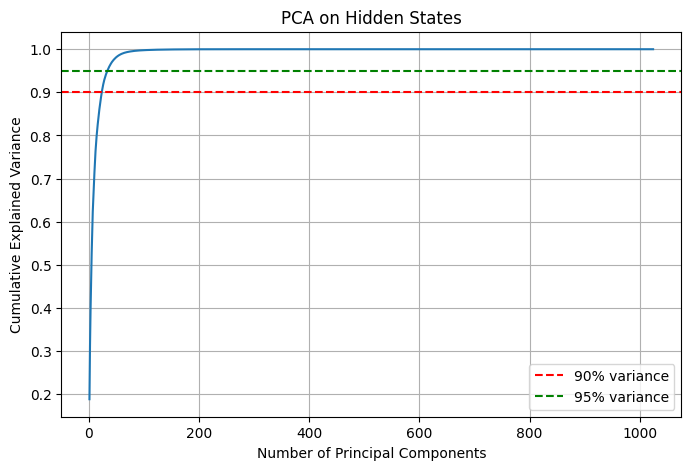

In [30]:
# Standardize (center, scale to unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Cumulative explained variance
explained_var = pca.explained_variance_ratio_
cumulative = np.cumsum(explained_var)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative)+1), cumulative)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA on Hidden States')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Find number of components needed for 90% variance
k = np.argmax(cumulative > 0.9)

# Fit PCA again with n_components = k
pca_k = PCA(n_components=k)
X_reduced = pca_k.fit_transform(X_scaled)
print(f"Reduced shape: {X_reduced.shape}")
print(f"Explained variance: {cumulative[k]}")

Reduced shape: (299061, 23)
Explained variance: 0.9050962328910828


Create a copy of records with reduced hidden vectors:

In [32]:
contextual_records_reduced = contextual_records.copy()

for i, record in enumerate(contextual_records_reduced):
    hidden_reduced = X_reduced[i, :]
    record['hidden'] = hidden_reduced

In [33]:
contextual_records[0]['hidden'].shape

(23,)

Updating the pair similarity data:

In [34]:
!rm -rf /kaggle/working/pca_contextual_pair_similarities.csv

In [35]:
# Write to CSV (same as before)
out_fname = 'pca_contextual_pair_similarities_balanced.csv'
with open(out_fname, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['char_i', 'char_j', 'pinyin_i', 'pinyin_j', 'hidden_sim', 'semantic_sim',
                     'acoustic_sim', 'wubi_jaccard', 'same_initial_final', 'same_initial',
                     'same_final', 'same_tone'])
    # for (cat, bin_idx), pair_list in tqdm(strata.items(), desc="Writing CSV"):
    for cat, pair_list in tqdm(strata.items(), desc="Writing CSV"):
        for i, j in pair_list:
            rec_i = contextual_records[i]
            rec_j = contextual_records[j]
            h_sim = cosine_similarity(rec_i['hidden'], rec_j['hidden'])
            s_sim = cosine_similarity(rec_i['semantic'], rec_j['semantic'])
            a_sim = cosine_similarity(rec_i['acoustic'], rec_j['acoustic'])
            w_jac = jaccard_similarity(rec_i['wubi_set'], rec_j['wubi_set'])
            sf, si, sf_, st = pinyin_flags(rec_i['pinyin_components'], rec_j['pinyin_components'])
            writer.writerow([rec_i['char'], rec_j['char'], rec_i['pinyin'], rec_j['pinyin'],
                             h_sim, s_sim, a_sim, w_jac, sf, si, sf_, st])

print(f"Saved balanced dataset to {out_fname}")

Writing CSV: 100%|██████████| 5/5 [00:01<00:00,  3.93it/s]

Saved balanced dataset to pca_contextual_pair_similarities_balanced.csv


In [36]:
similarity_df_reduced = pd.read_csv("/kaggle/working/pca_contextual_pair_similarities_balanced.csv")

In [37]:
similarity_df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24501 entries, 0 to 24500
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   char_i              24501 non-null  object 
 1   char_j              24501 non-null  object 
 2   pinyin_i            24501 non-null  object 
 3   pinyin_j            24501 non-null  object 
 4   hidden_sim          24501 non-null  float64
 5   semantic_sim        24501 non-null  float64
 6   acoustic_sim        24501 non-null  float64
 7   wubi_jaccard        24501 non-null  float64
 8   same_initial_final  24501 non-null  int64  
 9   same_initial        24501 non-null  int64  
 10  same_final          24501 non-null  int64  
 11  same_tone           24501 non-null  int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 2.2+ MB


In [38]:
similarity_df_reduced.describe()

,hidden_sim,semantic_sim,acoustic_sim,wubi_jaccard,same_initial_final,same_initial,same_final,same_tone
count,24501.000000,24501.000000,24501.000000,24501.000000,24501.000000,24501.000000,24501.000000,24501.000000
mean,0.218828,0.314889,0.198928,0.068407,0.183707,0.204073,0.204073,0.204073
std,0.356164,0.219994,0.278115,0.131026,0.387253,0.403031,0.403031,0.403031
min,-0.751600,-0.204717,-0.486336,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.057080,0.142622,-0.014229,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.209254,0.285151,0.164685,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.499302,0.462863,0.404347,0.142857,0.000000,0.000000,0.000000,0.000000
max,0.998645,0.966117,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: xlabel='hidden_sim', ylabel='Density'>

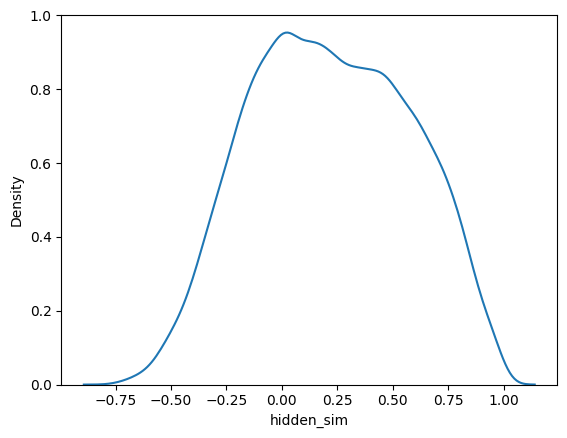

In [39]:
import seaborn as sns

sns.kdeplot(similarity_df_reduced, x='hidden_sim')

In [40]:
similarity_df_reduced[similarity_df_reduced['hidden_sim'] > 0.9]

,char_i,char_j,pinyin_i,pinyin_j,hidden_sim,semantic_sim,acoustic_sim,wubi_jaccard,same_initial_final,same_initial,same_final,same_tone
99,评,平,ping2,ping2,0.994655,0.915245,1.000000,0.666667,0,0,0,0
635,中,终,zhong1,zhong1,0.998645,0.966117,1.000000,0.000000,0,0,0,0
1325,斯,司,si1,si1,0.975050,0.963564,1.000000,0.000000,0,0,0,0
1500,加,家,jia1,jia1,0.970934,0.915856,1.000000,0.000000,0,0,0,0
1505,是,释,shi4,shi4,0.991868,0.933410,1.000000,0.000000,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
24422,脂,只,zhi1,zhi3,0.905610,0.767736,0.488004,0.000000,1,0,0,0
24429,仪,椅,yi2,yi3,0.939975,0.521204,0.809398,0.000000,1,0,0,0
24430,已,姨,yi3,yi2,0.944636,0.517517,0.809398,0.000000,1,0,0,0
24491,余,予,yu2,yu3,0.972987,0.609535,0.949675,0.000000,1,0,0,0


### Train/Test Split

In [41]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import r2_score


X = similarity_df_reduced[[
    'semantic_sim',
    'acoustic_sim',
    'wubi_jaccard',
    'same_initial_final',
    'same_initial',
    'same_final',
    'same_tone',
    'char_i',
    'char_j'
]]

X = sm.add_constant(X)

y = similarity_df_reduced['hidden_sim']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scaling

In [42]:
from sklearn.preprocessing import StandardScaler

scaling_columns = ['semantic_sim', 'acoustic_sim', 'wubi_jaccard']

scaler = StandardScaler()

# Fit on train data
scaled_array = scaler.fit_transform(X_train[scaling_columns])
for i, col in enumerate(scaling_columns):
    X_train[col + '_scaled'] = scaled_array[:, i]

# Tranform only for test data
scaled_array = scaler.transform(X_test[scaling_columns])
for i, col in enumerate(scaling_columns):
    X_test[col + '_scaled'] = scaled_array[:, i]

# For OLS interface, unite X and y
train_data = X_train.copy()
train_data['hidden_sim'] = y_train

# Final set of predictors
feature_names = [
    'const', 'semantic_sim_scaled', 'acoustic_sim_scaled',
    'wubi_jaccard_scaled', 'same_initial_final', 'same_initial',
    'same_final', 'same_tone'
]

In [43]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define the formula
formula = 'hidden_sim ~ semantic_sim_scaled + acoustic_sim_scaled + wubi_jaccard_scaled + same_initial_final + same_initial + same_final + same_tone'

# Fit OLS model
model = smf.ols(formula, data=train_data).fit(cov_type='HC3')

# Print summary with robust standard errors
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             hidden_sim   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     6934.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        14:13:58   Log-Likelihood:                 3317.0
No. Observations:               19600   AIC:                            -6618.
Df Residuals:                   19592   BIC:                            -6555.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.2777    

In [44]:
from sklearn.metrics import r2_score, root_mean_squared_error

y_pred = model.predict(X_test)

print("Modeling Results (PCA Reduction):")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"R^2: {r2_score(y_test, y_pred):.4f}")

Modeling Results (PCA Reduction):
RMSE: 0.2025
R^2: 0.6798


## Multicollinearity Test

Variance Inflation Factor for each variable is tested to verify the absence of multicollinearity in data.

In [45]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = feature_names
vif_data["VIF"] = [variance_inflation_factor(X_train[feature_names].values, i) for i in range(X_train[feature_names].shape[1])]
print(vif_data)

              Variable       VIF
0                const  9.163493
1  semantic_sim_scaled  2.507884
2  acoustic_sim_scaled  2.164493
3  wubi_jaccard_scaled  1.006193
4   same_initial_final  4.513244
5         same_initial  2.383036
6           same_final  2.744856
7            same_tone  1.877643


## Linearity and Heteroscedasticity

### Residuals and Q-Q plots

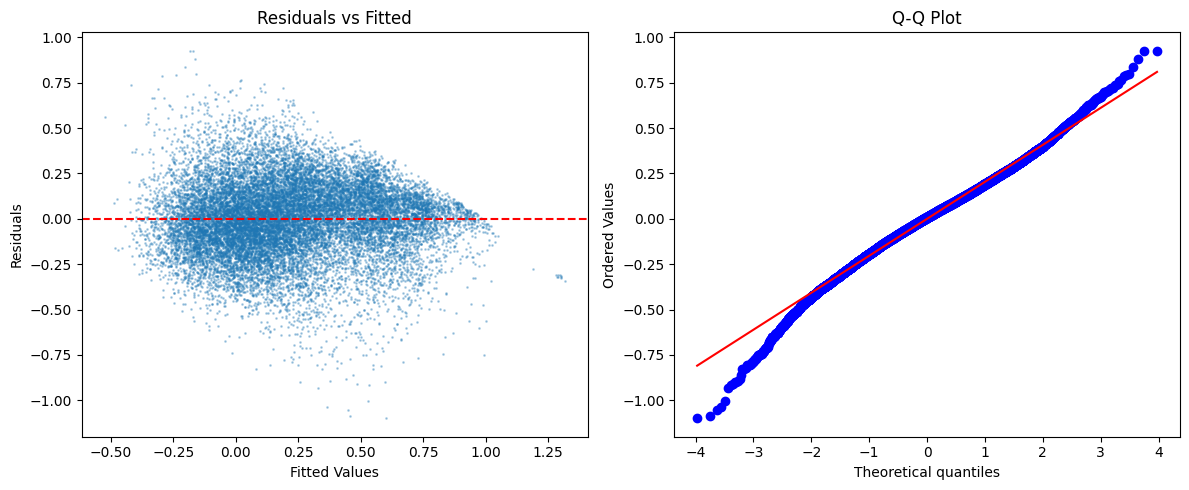

In [46]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Fit OLS model again to get residuals
model = sm.OLS(y_train, X_train[feature_names]).fit(cov_type='HC3')
residuals = model.resid
fitted = model.fittedvalues

# Residuals vs fitted plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(fitted, residuals, alpha=0.3, s=1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

# Q-Q plot for normality
plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.tight_layout()
plt.show()

### Breusch-Pagan and Ramsey Reset Test

### Breusch–Pagan Test
Tests heteroscedasticity

$H_0$: constant variance

In [47]:
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
import statsmodels.api as sm


model = sm.OLS(y_train, X_train[feature_names]).fit(cov_type='HC3')

In [48]:
bp_test = het_breuschpagan(model.resid, model.model.exog)

bp_labels = [
    'Lagrange multiplier statistic',
    'p-value',
    'f-value',
    'f p-value'
]

print("\n=== Breusch–Pagan Test ===")
for name, value in zip(bp_labels, bp_test):
    print(f"{name}: {value:.6f}")

# Interpretation
if bp_test[1] < 0.05:
    print("\nResult: heteroscedasticity detected.")
else:
    print("\nResult: no significant heteroscedasticity detected.")


=== Breusch–Pagan Test ===
Lagrange multiplier statistic: 1154.109956
p-value: 0.000000
f-value: 175.116998
f p-value: 0.000000

Result: heteroscedasticity detected.


### Ramsey RESET Test

Tests omitted nonlinear structure

$H_0$: model is correctly specified

In [49]:
reset_test = linear_reset(
    model,
    power=2,          # adds squared fitted values
    use_f=True
)

print("\n=== Ramsey RESET Test ===")
print(f"F-statistic: {reset_test.fvalue:.6f}")
print(f"p-value: {reset_test.pvalue:.6f}")

# Interpretation
if reset_test.pvalue < 0.05:
    print("\nResult: evidence of missing nonlinear structure.")
else:
    print("\nResult: linear specification appears sufficient.")


=== Ramsey RESET Test ===
F-statistic: 83.846038
p-value: 0.000000

Result: evidence of missing nonlinear structure.


### Fisher Transform

$h \in [-1, 1]$,

$z = \text{arctanh}(h) $

In [50]:
train_data['hidden_sim_z'] = np.arctanh(
    np.clip(train_data['hidden_sim'], -0.999999, 0.999999)
)

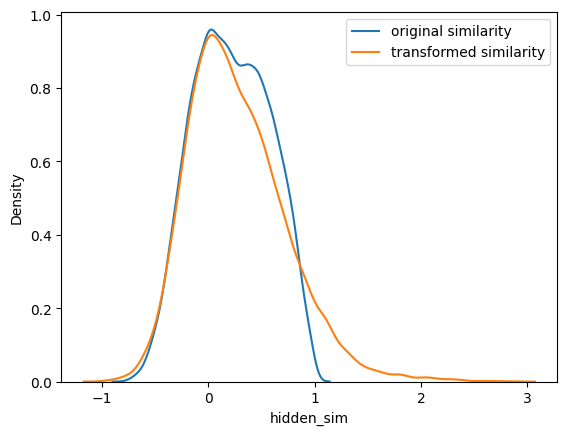

In [51]:
import seaborn as sns

sns.kdeplot(train_data, x='hidden_sim', label='original similarity')
sns.kdeplot(train_data, x='hidden_sim_z', label='transformed similarity')

plt.legend()

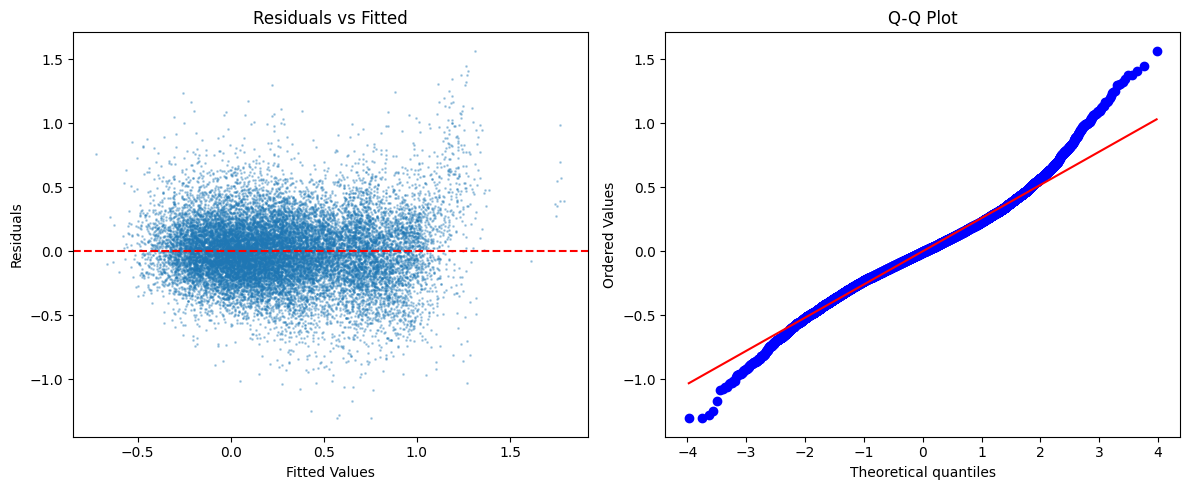

In [52]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Fit OLS model again to get residuals
model = sm.OLS(train_data['hidden_sim_z'], X_train[feature_names]).fit(cov_type='HC3')
residuals = model.resid
fitted = model.fittedvalues

# Residuals vs fitted plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(fitted, residuals, alpha=0.3, s=1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

# Q-Q plot for normality
plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.tight_layout()
plt.show()

In [53]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           hidden_sim_z   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     4215.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        14:14:03   Log-Likelihood:                -1526.4
No. Observations:               19600   AIC:                             3069.
Df Residuals:                   19592   BIC:                             3132.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.3993    

In [54]:
from sklearn.metrics import r2_score, root_mean_squared_error

y_pred = model.predict(X_test[feature_names])

y_true = np.arctanh(
    np.clip(y_test, -0.999999, 0.999999)
)

print("Modeling Results (Fisher Transform):")
print(f"RMSE: {root_mean_squared_error(y_true, y_pred):.3f}")
print(f"R^2: {r2_score(y_true, y_pred):.3f}")

Modeling Results (Fisher Transform):
RMSE: 0.262
R^2: 0.680


## Cross-Validation

5-fold cross validation of $R^2$ metric

In [55]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression


cv = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()
scores = cross_val_score(lr, X_train[feature_names], y_train, cv=cv, scoring='r2')

print(f"Cross-validated R²: mean = {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Individual fold R²: {scores}")

Cross-validated R²: mean = 0.6696 ± 0.0051
Individual fold R²: [0.67232563 0.67442238 0.66476572 0.67429999 0.66238614]


## Non-linear Modeling

### Combinational Features

In [56]:
# X_train['acoustic_same_initial_final'] = X_train['acoustic_sim'] * X_train['same_initial_final']
X_train['acoustic_same_initial'] = X_train['acoustic_sim'] * X_train['same_initial']
X_train['acoustic_same_final'] = X_train['acoustic_sim'] * X_train['same_final']
X_train['acoustic_same_tone'] = X_train['acoustic_sim'] * X_train['same_tone']
X_train['acoustic_wubi'] = X_train['acoustic_sim'] * X_train['wubi_jaccard']
X_train['semantic_wubi'] = X_train['semantic_sim'] * X_train['wubi_jaccard']

In [57]:
# X_test['acoustic_same_initial_final'] = X_test['acoustic_sim'] * X_test['same_initial_final']
X_test['acoustic_same_initial'] = X_test['acoustic_sim'] * X_test['same_initial']
X_test['acoustic_same_final'] = X_test['acoustic_sim'] * X_test['same_final']
X_test['acoustic_same_tone'] = X_test['acoustic_sim'] * X_test['same_tone']
X_test['acoustic_wubi'] = X_test['acoustic_sim'] * X_test['wubi_jaccard']
X_test['semantic_wubi'] = X_test['semantic_sim'] * X_test['wubi_jaccard']

In [58]:
comb_feature_names = feature_names + [
    'acoustic_same_initial',
    'acoustic_same_final',
    'acoustic_same_tone',
    'acoustic_wubi',
    'semantic_wubi'
]

In [59]:
import statsmodels.api as sm


comb_model = sm.OLS(y_train, X_train[comb_feature_names]).fit(cov_type='HC3')

In [60]:
print(comb_model.summary())

                            OLS Regression Results                            
Dep. Variable:             hidden_sim   R-squared:                       0.672
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     4129.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        14:14:06   Log-Likelihood:                 3378.7
No. Observations:               19600   AIC:                            -6731.
Df Residuals:                   19587   BIC:                            -6629.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.25

In [61]:
from sklearn.metrics import r2_score, root_mean_squared_error

y_pred = comb_model.predict(X_test[comb_feature_names])

print("Modeling Results (PCA Reduction):")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"R^2: {r2_score(y_test, y_pred):.4f}")

Modeling Results (PCA Reduction):
RMSE: 0.2019
R^2: 0.6819


### Polynomial Features

In [62]:
# Polynomial (quadratic) features for continuous variables
X_train['acoustic_sim_sq'] = X_train['acoustic_sim'] ** 2
X_train['semantic_sim_sq'] = X_train['semantic_sim'] ** 2
X_train['wubi_jaccard_sq'] = X_train['wubi_jaccard'] ** 2

# Cross-polynomial interactions
X_train['acoustic_semantic'] = (
    X_train['acoustic_sim'] * X_train['semantic_sim']
)

X_train['acoustic_wubi'] = (
    X_train['acoustic_sim'] * X_train['wubi_jaccard']
)

X_train['semantic_wubi'] = (
    X_train['semantic_sim'] * X_train['wubi_jaccard']
)

In [63]:
# Polynomial (quadratic) features for continuous variables
X_test['acoustic_sim_sq'] = X_test['acoustic_sim'] ** 2
X_test['semantic_sim_sq'] = X_test['semantic_sim'] ** 2
X_test['wubi_jaccard_sq'] = X_test['wubi_jaccard'] ** 2

# Cross-polynomial interactions
X_test['acoustic_semantic'] = (
    X_test['acoustic_sim'] * X_test['semantic_sim']
)

X_test['acoustic_wubi'] = (
    X_test['acoustic_sim'] * X_test['wubi_jaccard']
)

X_test['semantic_wubi'] = (
    X_test['semantic_sim'] * X_test['wubi_jaccard']
)

In [64]:
poly_feature_names = feature_names + [
    'acoustic_sim_sq',
    'semantic_sim_sq',
    'wubi_jaccard_sq',
    'acoustic_semantic',
    'acoustic_wubi',
    'semantic_wubi',
]

In [65]:
import statsmodels.api as sm


poly_model = sm.OLS(y_train, X_train[poly_feature_names]).fit(cov_type='HC3')

In [66]:
print(poly_model.summary())

                            OLS Regression Results                            
Dep. Variable:             hidden_sim   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     4208.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        14:14:07   Log-Likelihood:                 3584.1
No. Observations:               19600   AIC:                            -7140.
Df Residuals:                   19586   BIC:                            -7030.
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.2673    

In [67]:
from sklearn.metrics import r2_score, root_mean_squared_error

y_pred = poly_model.predict(X_test[poly_feature_names])

print("Modeling Results (PCA Reduction):")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"R^2: {r2_score(y_test, y_pred):.4f}")

Modeling Results (PCA Reduction):
RMSE: 0.2000
R^2: 0.6878


### All non-linear features

In [68]:
extended_feature_names = feature_names + [
    'acoustic_same_initial',
    'acoustic_same_final',
    'acoustic_same_tone',

    'acoustic_sim_sq',
    'semantic_sim_sq',
    'wubi_jaccard_sq',
    'acoustic_semantic',
    'acoustic_wubi',
    'semantic_wubi',
]

In [69]:
import statsmodels.api as sm


extended_model = sm.OLS(y_train, X_train[extended_feature_names]).fit(cov_type='HC3')

In [70]:
print(extended_model.summary())

                            OLS Regression Results                            
Dep. Variable:             hidden_sim   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     3472.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        14:14:08   Log-Likelihood:                 3606.5
No. Observations:               19600   AIC:                            -7179.
Df Residuals:                   19583   BIC:                            -7045.
Df Model:                          16                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.25

In [71]:
from sklearn.metrics import r2_score, root_mean_squared_error

y_pred = extended_model.predict(X_test[extended_feature_names])

print("Modeling Results (PCA Reduction):")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"R^2: {r2_score(y_test, y_pred):.4f}")

Modeling Results (PCA Reduction):
RMSE: 0.1998
R^2: 0.6884


In [72]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = extended_feature_names
vif_data["VIF"] = [variance_inflation_factor(X_train[extended_feature_names].values, i) for i in range(X_train[extended_feature_names].shape[1])]
print(vif_data)

                 Variable        VIF
0                   const  47.257401
1     semantic_sim_scaled  21.171638
2     acoustic_sim_scaled  12.989479
3     wubi_jaccard_scaled   5.783744
4      same_initial_final   9.087624
5            same_initial   3.864210
6              same_final   5.062639
7               same_tone   2.895252
8   acoustic_same_initial   2.632757
9     acoustic_same_final   4.725118
10     acoustic_same_tone   2.207382
11        acoustic_sim_sq   6.394540
12        semantic_sim_sq  25.802297
13        wubi_jaccard_sq   4.485210
14      acoustic_semantic  18.569160
15          acoustic_wubi   3.299043
16          semantic_wubi   6.389159


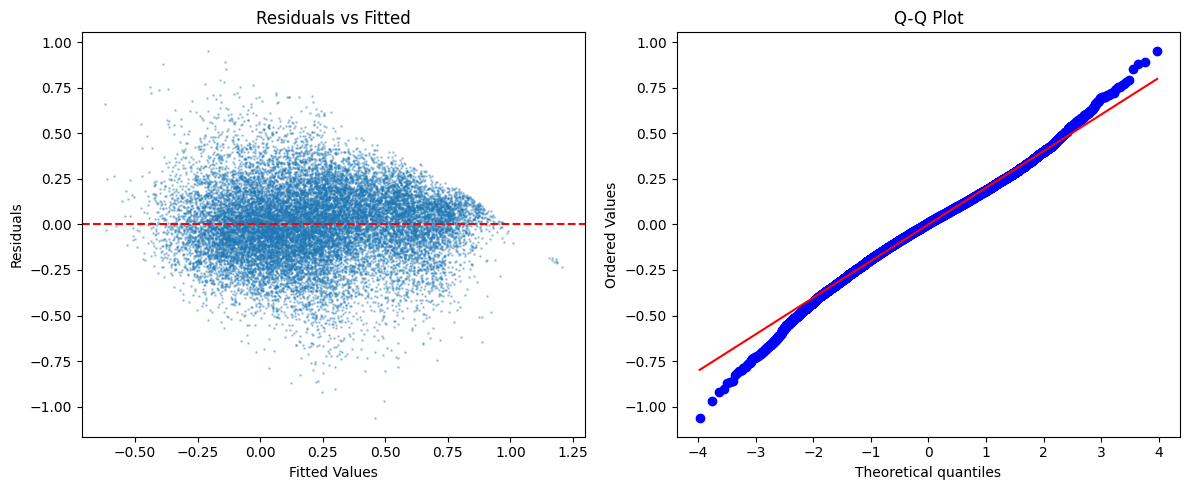

In [73]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Fit OLS model again to get residuals
model = sm.OLS(y_train, X_train[extended_feature_names]).fit(cov_type='HC3')
residuals = model.resid
fitted = model.fittedvalues

# Residuals vs fitted plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(fitted, residuals, alpha=0.3, s=1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

# Q-Q plot for normality
plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.tight_layout()
plt.show()

### Decision Tree

Another highly interpretable non-linear interaction model is a decision tree:

In [74]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Hyperparameter tuning using K-Fold cross-validation
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}
dt = DecisionTreeRegressor(random_state=42)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=kfold, scoring='r2', n_jobs=-1)
grid_search.fit(X_train[feature_names], y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Best parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV R²: 0.6686544583966663


In [75]:
# Fit the best model on entire training set
best_dt = grid_search.best_estimator_
best_dt.fit(X_train[feature_names], y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [76]:
# Evaluate on test set
y_pred = best_dt.predict(X_test[feature_names])
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

Test RMSE: 0.2028
Test R²: 0.6790



Decision Tree structure:
 |--- acoustic_sim_scaled <= -0.15
|   |--- acoustic_sim_scaled <= -0.81
|   |   |--- acoustic_sim_scaled <= -1.31
|   |   |   |--- acoustic_sim_scaled <= -1.58
|   |   |   |   |--- acoustic_sim_scaled <= -1.93
|   |   |   |   |   |--- value: [-0.38]
|   |   |   |   |--- acoustic_sim_scaled >  -1.93
|   |   |   |   |   |--- value: [-0.29]
|   |   |   |--- acoustic_sim_scaled >  -1.58
|   |   |   |   |--- semantic_sim_scaled <= -1.06
|   |   |   |   |   |--- value: [-0.25]
|   |   |   |   |--- semantic_sim_scaled >  -1.06
|   |   |   |   |   |--- value: [-0.19]
|   |   |--- acoustic_sim_scaled >  -1.31
|   |   |   |--- acoustic_sim_scaled <= -1.13
|   |   |   |   |--- semantic_sim_scaled <= -0.98
|   |   |   |   |   |--- value: [-0.18]
|   |   |   |   |--- semantic_sim_scaled >  -0.98
|   |   |   |   |   |--- value: [-0.11]
|   |   |   |--- acoustic_sim_scaled >  -1.13
|   |   |   |   |--- semantic_sim_scaled <= 0.00
|   |   |   |   |   |--- value: [-0.08]
|   

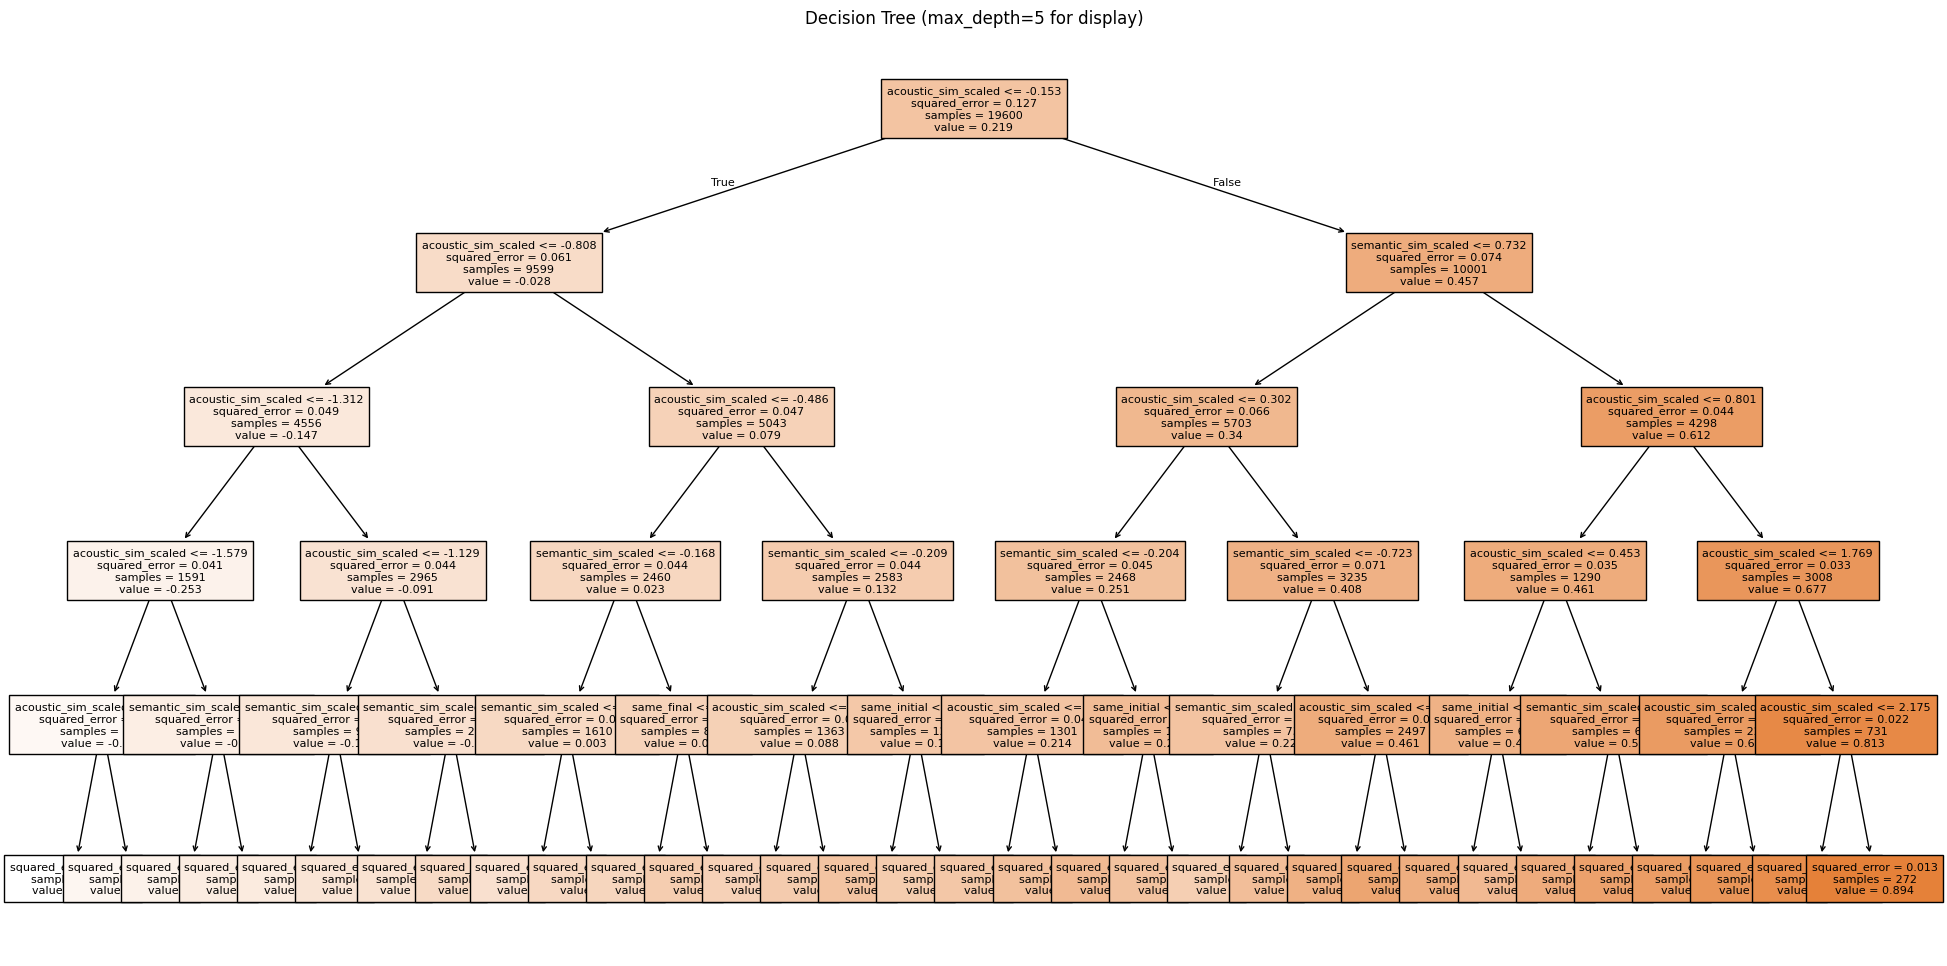

In [77]:
# Print tree (as text or plot)
# Text representation (limited depth)
tree_text = export_text(best_dt, feature_names=feature_names, max_depth=10)
print("\nDecision Tree structure:\n", tree_text)

# Plot the tree
plt.figure(figsize=(24, 12))
plot_tree(best_dt, feature_names=feature_names, filled=True, max_depth=20, fontsize=8)
plt.title("Decision Tree (max_depth=5 for display)")
plt.show()

### Gradient Boosting

Non-linear effects are detected, the gradient boosting approach is used to verify the design sufficiency ($R^2$ increase):

In [78]:
import xgboost as xgb

# XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train[feature_names], y_train)

y_pred = xgb_model.predict(X_test[feature_names])
r2_xgb = r2_score(y_test, y_pred)
rmse_xgb = root_mean_squared_error(y_test, y_pred)
print(f"XGBoost RMSE on test set: {rmse_xgb:.3f}")
print(f"XGBoost R^2 on test set: {r2_xgb:.3f}")

# Feature importance
importance = pd.DataFrame({'feature': feature_names, 'importance': xgb_model.feature_importances_})
print(importance.sort_values('importance', ascending=False))

XGBoost RMSE on test set: 0.195
XGBoost R^2 on test set: 0.703
               feature  importance
2  acoustic_sim_scaled    0.678941
1  semantic_sim_scaled    0.126943
4   same_initial_final    0.061987
5         same_initial    0.052569
6           same_final    0.045596
7            same_tone    0.022685
3  wubi_jaccard_scaled    0.011278
0                const    0.000000


## SHAP Values

In [79]:
import shap

### Linear Model

**General SHAP Values**:

In [80]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train[feature_names], y_train)

LinearRegression()

In [81]:
explainer = shap.LinearExplainer(lr, X_test[feature_names])
shap_values = explainer(X_test[feature_names])

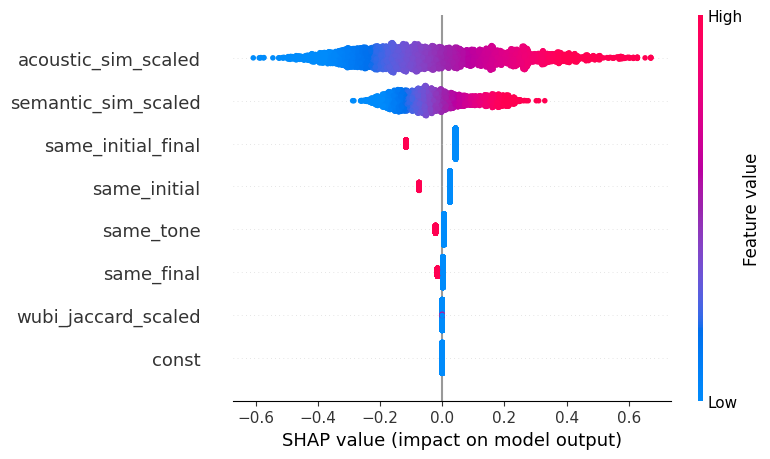

In [82]:
# Summary plot
shap.summary_plot(shap_values, X_test[feature_names])

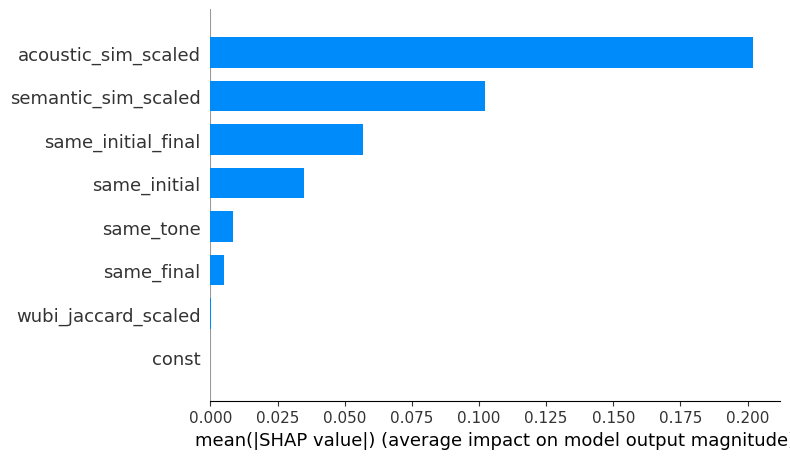

In [83]:
shap.summary_plot(shap_values, X_test[feature_names], plot_type="bar")

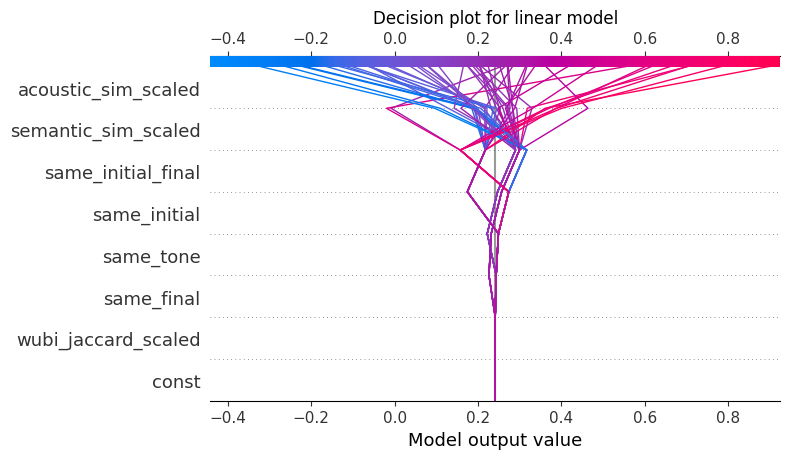

In [84]:
shap.decision_plot(
    base_value=shap_values.base_values[0],
    shap_values=shap_values.values[:50],
    features=X_test[feature_names].iloc[:50],
    feature_names=feature_names,
    link='identity',          # if your model outputs probabilities; default 'identity'
    # plot_color='red',      # line color(s)
    show=False             # to later modify or save
)
plt.title('Decision plot for linear model')
plt.tight_layout()
plt.show()

**Waterfall plots**:

In [85]:
sample_ids = np.random.choice(X_train.shape[0], 100, replace=False)

background = X_train.iloc[sample_ids, :]
background = background[feature_names]

In [86]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train[feature_names], y_train)

y_pred = lr.predict(X_test[feature_names])

print(r2_score(y_test, y_pred))

0.6797753717486803


In [87]:
explainer = shap.LinearExplainer(lr, background)
shap_values = explainer(background)

In [88]:
sim_test_for_examples = lr.predict(X_test[feature_names])
ranked_positions = np.argsort(sim_test_for_examples)[::-1]

k_selected = 5

sim_topk = sim_test_for_examples[ranked_positions[:k_selected]]
sim_bottomk = sim_test_for_examples[ranked_positions[-k_selected:]]

topk = X_test.iloc[ranked_positions[:k_selected], :][feature_names]
bottomk = X_test.iloc[ranked_positions[-k_selected:], :][feature_names]

shap_values_topk = explainer(topk)
shap_values_bottomk = explainer(bottomk)

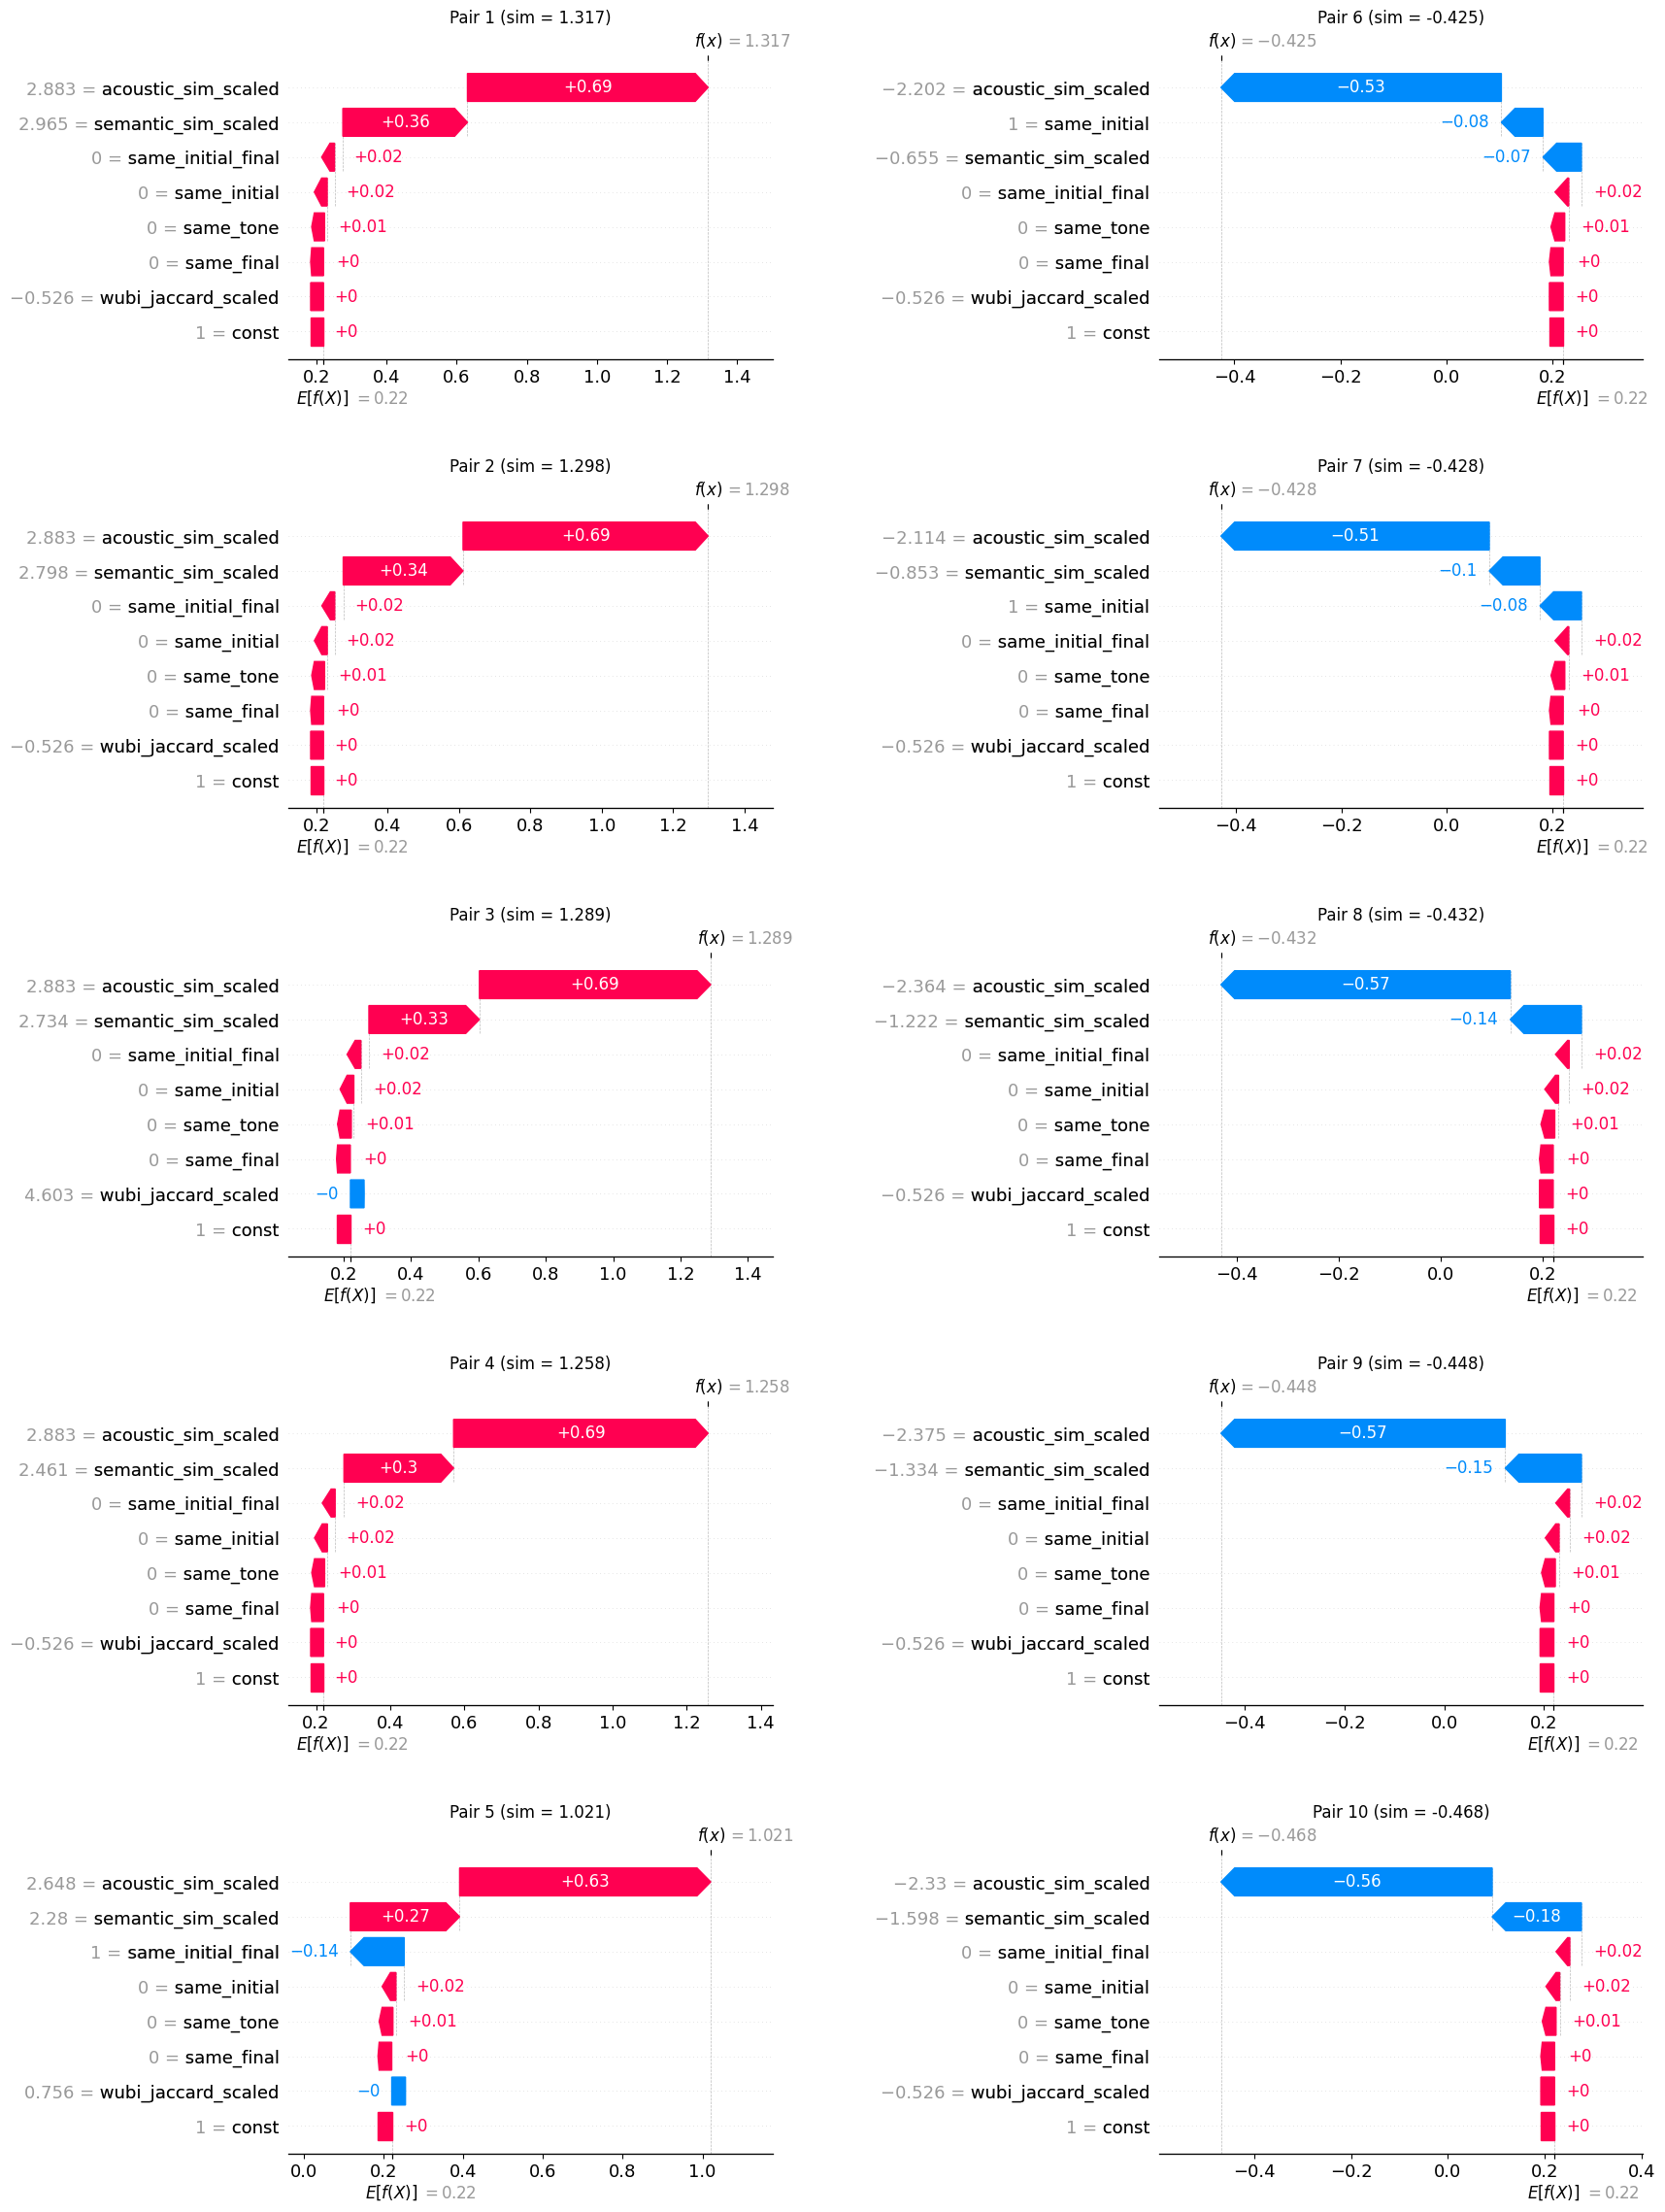

In [89]:
import matplotlib.pyplot as plt
import shap

# Create the grid (figsize will be overridden later)
fig, axes = plt.subplots(5, 2)
axes = axes.T.flatten()

for i, ax in enumerate(axes):
    if i < k_selected:
        exp = shap_values_topk[i, :]
        sim = sim_topk[i]
    else:
        exp = shap_values_bottomk[i%k_selected, :]
        sim = sim_bottomk[i%k_selected]
    plt.sca(ax)
    shap.plots.waterfall(exp, show=False)
    ax.set_title(f"Pair {i+1} (sim = {sim:.3f})")


# Adjust overall figure size and spacing
fig.set_size_inches(18, 28)                  # width, height
plt.subplots_adjust(hspace=0.5, wspace=0.8)  # vertical & horizontal gaps
fig.savefig('shap_waterfall_lin.png', dpi=300, bbox_inches='tight')
plt.show()

### XGBoost

**General SHAP Values**:

In [90]:
import shap

explainer = shap.Explainer(xgb_model, X_test[feature_names], feature_names=feature_names)
shap_values = explainer(X_test[feature_names], check_additivity=False)

 96%|=================== | 4718/4901 [00:15<00:00]       

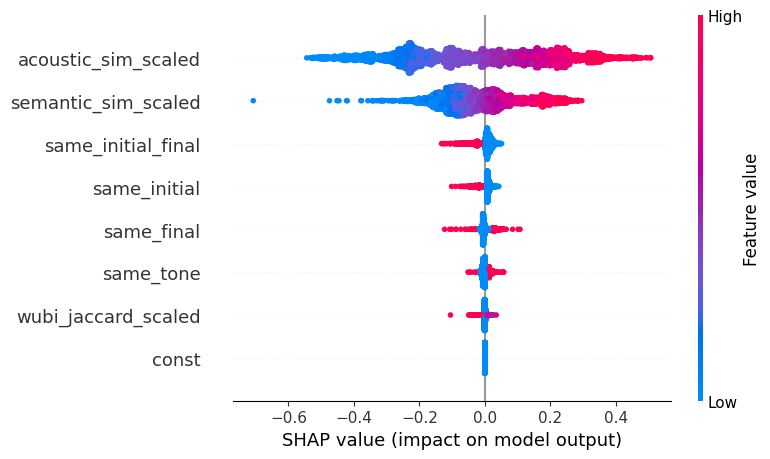

In [91]:
# Summary plot
shap.summary_plot(shap_values, X_test[feature_names])

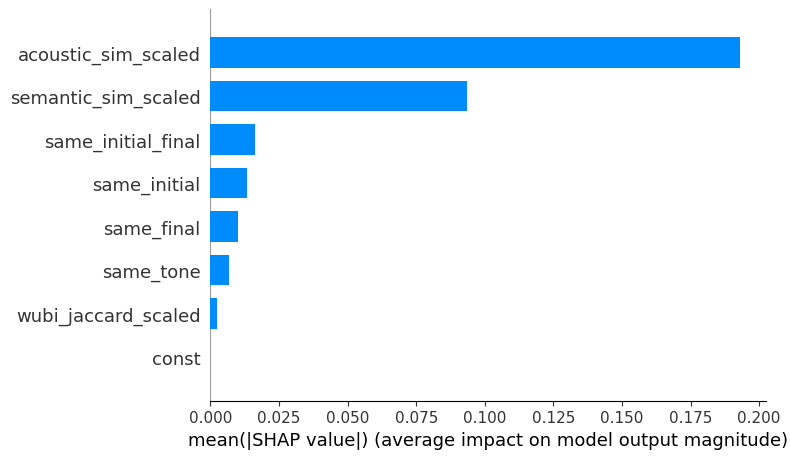

In [92]:
shap.summary_plot(shap_values, X_test[feature_names], plot_type="bar")

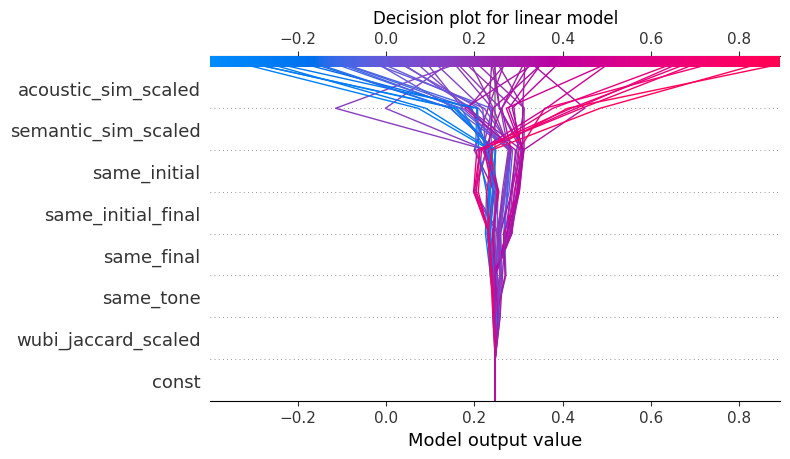

In [93]:
shap.decision_plot(
    base_value=shap_values.base_values[0],
    shap_values=shap_values.values[:50],
    features=X_test[feature_names].iloc[:50],
    feature_names=feature_names,
    link='identity',          # if your model outputs probabilities; default 'identity'
    # plot_color='red',      # line color(s)
    show=False             # to later modify or save
)
plt.title('Decision plot for linear model')
plt.tight_layout()
plt.show()

**Waterfall plots**:

In [94]:
sample_ids = np.random.choice(X_train.shape[0], 100, replace=False)

background = X_train.iloc[sample_ids, :]
background = background[feature_names]

In [95]:
import shap

explainer = shap.Explainer(xgb_model, background, feature_names=feature_names)
shap_values = explainer(background, check_additivity=False)

In [96]:
sim_test_for_examples = xgb_model.predict(X_test[feature_names])
ranked_positions = np.argsort(sim_test_for_examples)[::-1]

In [97]:
k_selected = 5

sim_topk = sim_test_for_examples[ranked_positions[:k_selected]]
sim_bottomk = sim_test_for_examples[ranked_positions[-k_selected:]]

topk = X_test.iloc[ranked_positions[:k_selected], :][feature_names]
bottomk = X_test.iloc[ranked_positions[-k_selected:], :][feature_names]

In [98]:
shap_values_topk = explainer(topk, check_additivity=False)
shap_values_bottomk = explainer(bottomk, check_additivity=False)

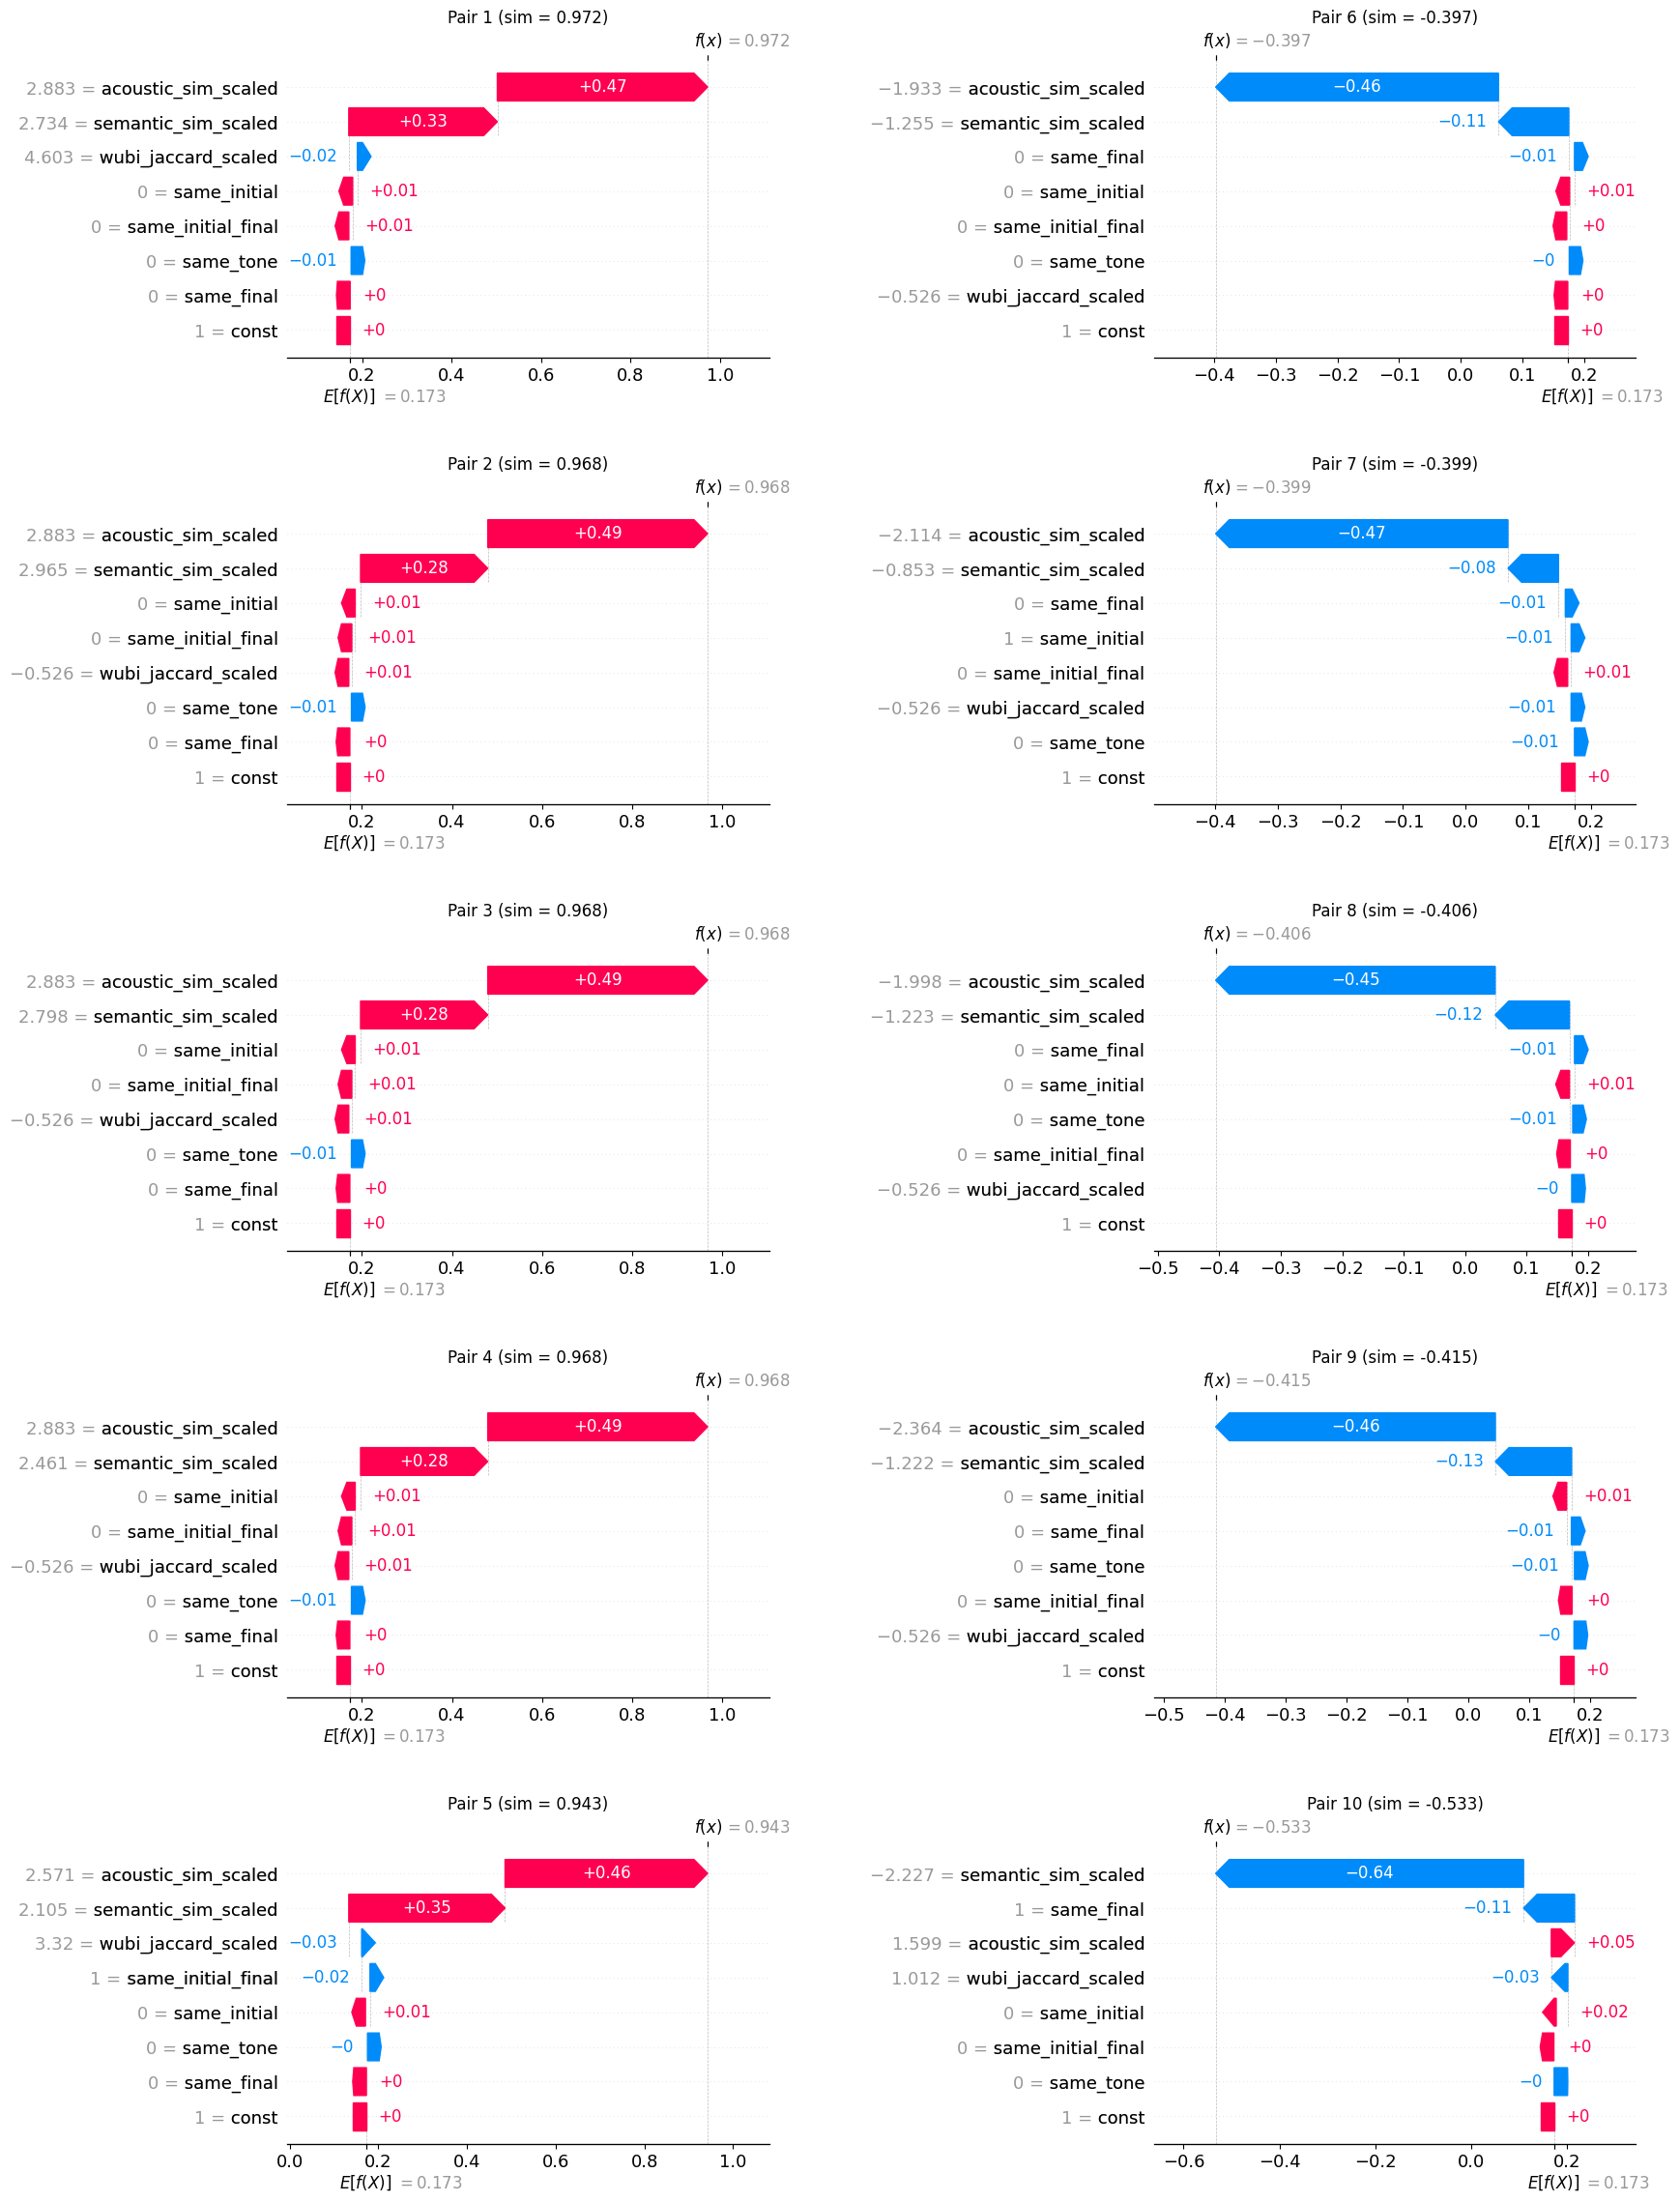

In [99]:
import matplotlib.pyplot as plt
import shap

# Create the grid (figsize will be overridden later)
fig, axes = plt.subplots(5, 2)
axes = axes.T.flatten()

for i, ax in enumerate(axes):
    if i < k_selected:
        exp = shap_values_topk[i, :]
        sim = sim_topk[i]
    else:
        exp = shap_values_bottomk[i%k_selected, :]
        sim = sim_bottomk[i%k_selected]
    plt.sca(ax)
    shap.plots.waterfall(exp, show=False)
    ax.set_title(f"Pair {i+1} (sim = {sim:.3f})")


# Adjust overall figure size and spacing
fig.set_size_inches(18, 28)                  # width, height
plt.subplots_adjust(hspace=0.5, wspace=0.8)  # vertical & horizontal gaps
fig.savefig('shap_waterfall_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

## Mixed Effects Modeling

In [100]:
!pip install -q statsmodels

In [101]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define variance components for two independent random intercepts
vc = {'char_i': '0 + C(char_i)', 'char_j': '0 + C(char_j)'}

# Fit model with only fixed effects (no random slopes)
md = smf.mixedlm(
    "hidden_sim ~ semantic_sim_scaled + acoustic_sim_scaled + wubi_jaccard_scaled + same_initial_final + same_initial + same_final + same_tone",
    train_data,
    groups=train_data['char_i'],  # needed for internal indexing
    vc_formula=vc
)
mdf = md.fit(method=['lbfgs'], maxiter=1000)
print(mdf.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   hidden_sim
No. Observations:    19600     Method:               REML      
No. Groups:          2409      Scale:                0.0264    
Min. group size:     1         Log-Likelihood:       3622.1114 
Max. group size:     278       Converged:            Yes       
Mean group size:     8.1                                       
---------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            0.287    0.005  59.206 0.000  0.277  0.296
semantic_sim_scaled  0.119    0.002  50.795 0.000  0.115  0.124
acoustic_sim_scaled  0.242    0.002 114.090 0.000  0.238  0.246
wubi_jaccard_scaled -0.000    0.001  -0.260 0.795 -0.003  0.002
same_initial_final  -0.176    0.008 -21.458 0.000 -0.192 -0.160
same_initial        -0.108    0.006 -19.255 0.000 -0.

In [102]:
from sklearn.metrics import r2_score, root_mean_squared_error

y_pred = mdf.predict(X_test)

print("Modeling Results (PCA Reduction):")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.3f}")
print(f"R^2: {r2_score(y_test, y_pred):.3f}")

Modeling Results (PCA Reduction):
RMSE: 0.203
R^2: 0.680
